# Análisis Exploratorio de Datos (EDA) - Calidad del Aire Valencia
Como Científico de Datos, el primer paso antes de diseñar las tablas de la base de datos o los dashboards es **entender la naturaleza de nuestros datos**. Buscamos:
1. Conocer el volumen y los tipos de datos.
2. Identificar la cantidad de valores nulos (missing values).
3. Ver la distribución de los contaminantes principales.
4. Descubrir patrones temporales o correlaciones relevantes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual para gráficos bonitos
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga de Datos

In [4]:
DATA_DIR = "../../data/raw/"
calidad_aire_path = os.path.join(DATA_DIR, "calidad-aire-2016.csv")

print("Cargando dataset...")
df = pd.read_csv(calidad_aire_path)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Cargando dataset...
Filas: 449,026
Columnas: 28


,_id,Fecha,Dia de la semana,Dia del mes,Hora,Estacion,PM1,PM2.5,PM10,NO,NO2,NOx,O3,SO2,CO,Velocidad del viento,Direccion del viento,NH3,C7H8,C6H6,Ruido,C8H10,Temperatura,Humedad relativa,Presion,Radiacion,Precipitacion,Velocidad maxima del viento
0,1,2020-01-01T00:00:00,Miércoles,1,0:00:00,Avda. Francia,NaN,77.0,83.0,16.0,45.0,69.0,3.0,7.0,0.2,1.3,313.0,NaN,NaN,NaN,NaN,NaN,6.6,89.0,1019.0,0.0,0.0,3.2
1,2,2020-01-01T00:00:00,Miércoles,1,1:00:00,Avda. Francia,NaN,65.0,70.0,20.0,37.0,68.0,3.0,5.0,0.2,1.9,315.0,NaN,NaN,NaN,NaN,NaN,6.2,89.0,1019.0,0.0,0.0,4.2
2,3,2020-01-01T00:00:00,Miércoles,1,2:00:00,Avda. Francia,NaN,47.0,51.0,16.0,35.0,61.0,3.0,5.0,0.1,2.2,316.0,NaN,NaN,NaN,NaN,NaN,5.9,90.0,1019.0,0.0,0.0,4.1
3,4,2020-01-01T00:00:00,Miércoles,1,3:00:00,Avda. Francia,NaN,43.0,46.0,16.0,29.0,53.0,3.0,5.0,0.1,1.7,310.0,NaN,NaN,NaN,NaN,NaN,5.5,90.0,1019.0,0.0,0.0,4.1
4,5,2020-01-01T00:00:00,Miércoles,1,4:00:00,Avda. Francia,NaN,36.0,39.0,10.0,23.0,39.0,3.0,4.0,0.1,1.2,312.0,NaN,NaN,NaN,NaN,NaN,5.3,89.0,1018.0,0.0,0.0,3.8


## 2. Inspección y Calidad del Dato (Data Quality)

/tmp/ipykernel_125344/3772773770.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette="Reds_r")


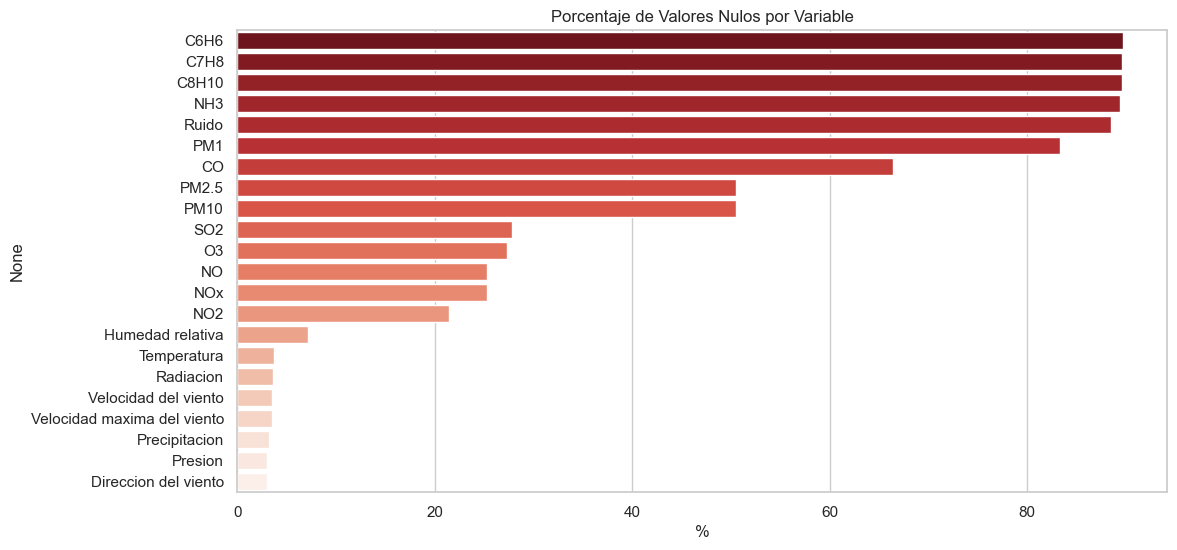

In [5]:
# Convertimos la Fecha a tipo datetime (esencial para series temporales)
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Vamos a ver el porcentaje de valores nulos por columna
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette="Reds_r")
plt.title("Porcentaje de Valores Nulos por Variable")
plt.xlabel("%")
plt.show()

## 3. Análisis Univariante (Distribución de Contaminantes)
Vamos a centrarnos en los contaminantes más críticos para la salud humana en las ciudades: **PM2.5, PM10, NO2 y O3**.

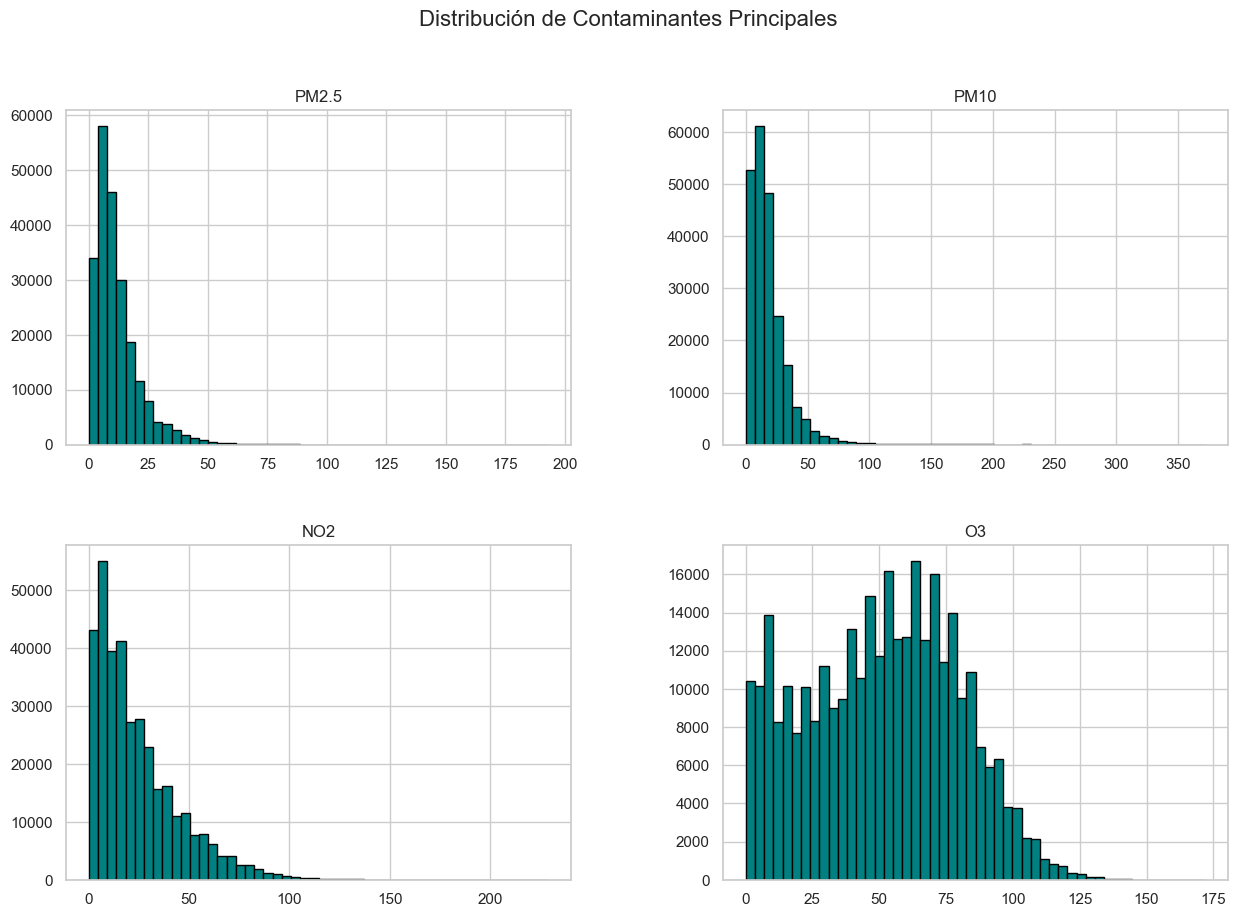

In [6]:
contaminantes = ['PM2.5', 'PM10', 'NO2', 'O3']

# Quitamos temporalmente los nulos para los histogramas
df[contaminantes].hist(bins=50, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Distribución de Contaminantes Principales', fontsize=16)
plt.show()

## 4. Evolución Temporal
¿Cómo varía la contaminación a lo largo del tiempo? Vamos a agrupar los datos por mes para ver si hay estacionalidad.

/tmp/ipykernel_125344/298498271.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensual = df.set_index('Fecha')[contaminantes].resample('M').mean()


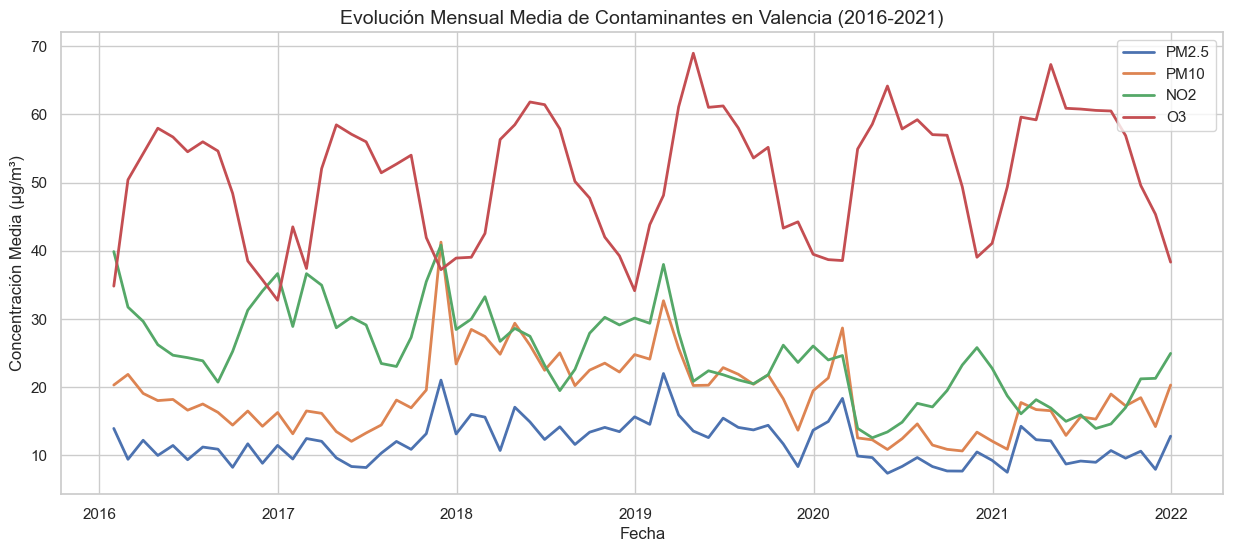

In [7]:
df_mensual = df.set_index('Fecha')[contaminantes].resample('M').mean()

plt.figure(figsize=(15, 6))
for col in contaminantes:
    plt.plot(df_mensual.index, df_mensual[col], label=col, linewidth=2)

plt.title('Evolución Mensual Media de Contaminantes en Valencia (2016-2021)', fontsize=14)
plt.ylabel('Concentración Media (µg/m³)')
plt.xlabel('Fecha')
plt.legend()
plt.show()

## 5. Análisis por Estación de Medición
¿Qué zonas de la ciudad registran peores valores medios de NO2 (típicamente asociado al tráfico)?

/tmp/ipykernel_125344/3470232782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=no2_por_estacion.values, y=no2_por_estacion.index, palette='viridis')


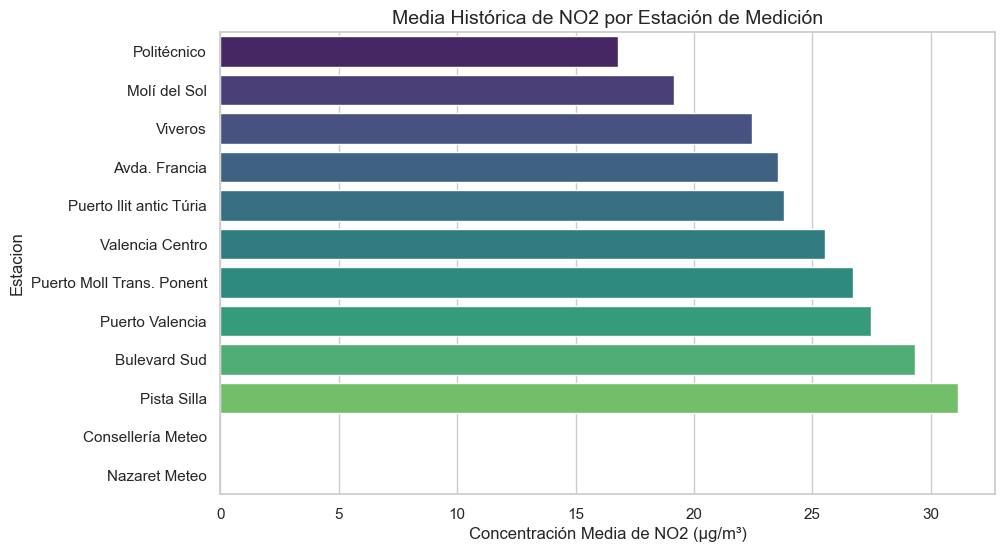

In [8]:
no2_por_estacion = df.groupby('Estacion')['NO2'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=no2_por_estacion.values, y=no2_por_estacion.index, palette='viridis')
plt.title('Media Histórica de NO2 por Estación de Medición', fontsize=14)
plt.xlabel('Concentración Media de NO2 (µg/m³)')
plt.show()

## 6. Correlaciones (Contaminación vs Clima)
¿El viento limpia la ciudad? ¿El calor afecta al ozono?

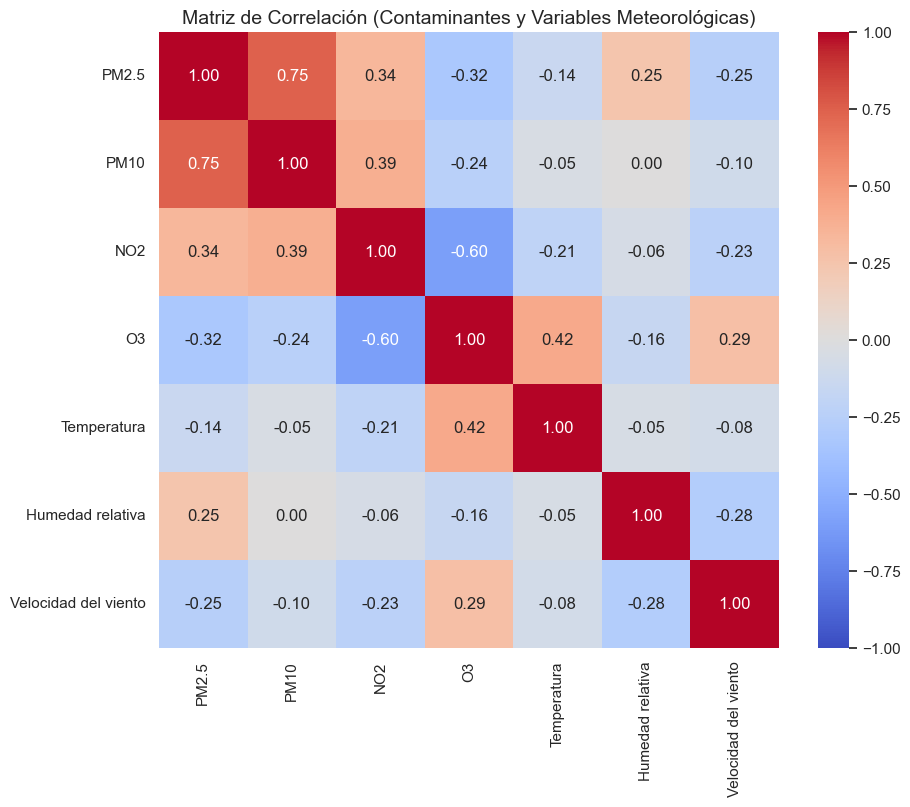

In [9]:
variables_corr = contaminantes + ['Temperatura', 'Humedad relativa', 'Velocidad del viento']
matriz_corr = df[variables_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Contaminantes y Variables Meteorológicas)', fontsize=14)
plt.show()

## 🎯 Conclusiones Clave para la Siguiente Fase (Ingesta y Dashboards)

1. **Gestión de Nulos:** Existen bastantes registros nulos en gases específicos (como NH3 o Tolueno). Para Logstash/Elasticsearch deberemos decidir si ignorar esos campos o rellenarlos con 0.
2. **El parseo de la fecha:** La columna `Fecha` es un string ISO (`2020-01-01T00:00:00`). Elasticsearch la mapeará perfectamente como `date`.
3. **Dashboard en Kibana:** Ya hemos validado qué gráficos serán más impactantes (Evolución temporal por meses, medias por estación en mapa de calor, y cruce de datos con la velocidad del viento).

Con esto validado, ¡estamos listos para configurar Logstash y subir estos datos a Elasticsearch!